# EMS741 Few-Shot Segmentation: Reptile

This notebook is formatted to run correctly on both JupyterHub and Colab by relying on environment variables for the dataset and importing all core functions from `core_methods.py`.

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Windows / OpenMP fix
print("KMP_DUPLICATE_LIB_OK =", os.environ.get("KMP_DUPLICATE_LIB_OK"))

%load_ext autoreload
%autoreload 2

from pathlib import Path
import zipfile, subprocess

!nvidia-smi -L || echo "No GPU visible"

# If the dataset is already available on the cluster, set EMS741_DATA_ROOT
# before starting Jupyter. Otherwise, it will download into the CWD.
DATA_ROOT = None

if DATA_ROOT is None:
    env_root = os.environ.get("EMS741_DATA_ROOT")
    DATA_ROOT = Path(env_root) if env_root else Path.cwd()

def has_dataset(root: Path):
    return all((root / s).exists() for s in ["train", "val", "test"])

if not has_dataset(DATA_ROOT):
    print(f"Dataset not found in {DATA_ROOT.resolve()}")
    print("Downloading dataset to current working directory...")
    url = "https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1"
    zip_path = Path("data.zip")
    if not zip_path.exists():
        subprocess.run(["wget", "-O", str(zip_path), url], check=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(Path.cwd())
    DATA_ROOT = Path.cwd()

print("DATA_ROOT:", DATA_ROOT.resolve())

KMP_DUPLICATE_LIB_OK = TRUE
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
GPU 0: NVIDIA A40 (UUID: GPU-258f158f-556e-619c-822d-349eda75d313)
DATA_ROOT: /home/jovyan/Git/QMUL-EMS741-Group-8


In [8]:
import torch
import numpy as np
import random

from core_methods import (
    UNet,
    SegDataset,
    FewShotEpisode,
    discover_tasks,
    reptile_meta_train,
    adapt_and_evaluate,
    train_baseline,
    unified_adapt_and_evaluate,
    bce_dice_loss,
    dice_score,
)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [9]:
train_tasks = discover_tasks(DATA_ROOT / "train")
val_tasks   = discover_tasks(DATA_ROOT / "val")
test_tasks  = discover_tasks(DATA_ROOT / "test")

print("Train tasks:", list(train_tasks.keys()))
print("Val tasks:",   list(val_tasks.keys()))
print("Test tasks:",  list(test_tasks.keys()))

Train tasks: ['task_2', 'task_3', 'task_5', 'task_7']
Val tasks: ['task_4', 'task_6']
Test tasks: ['task_1', 'task_8']


In [10]:
N_OUTER   = 1
K_INNER   = 5
INNER_LR  = 1e-3
META_LR   = 0.1
VAL_EVERY = 200

print("Starting Reptile meta-training...")
meta_model, meta_history = reptile_meta_train(
    train_tasks=train_tasks,
    val_tasks=val_tasks,
    n_outer=N_OUTER,
    k_inner=K_INNER,
    inner_lr=INNER_LR,
    meta_lr=META_LR,
    batch_size=4,
    val_every=VAL_EVERY,
    n_shot_val=5,
)

torch.save(meta_model.state_dict(), "meta_model.pth")
print("Meta-model saved to meta_model.pth")

Starting Reptile meta-training...


Meta-model saved to meta_model.pth


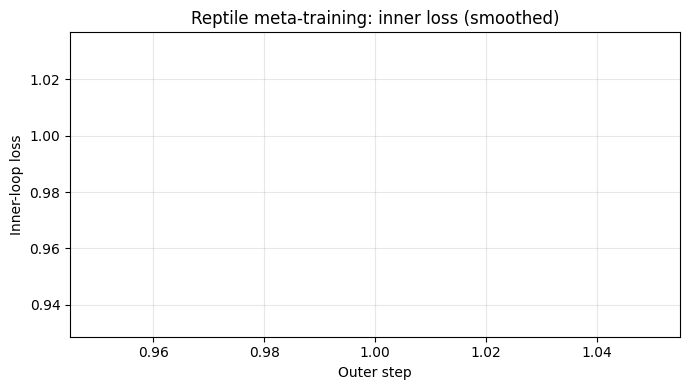

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Val Dice over outer steps
if meta_history["outer_step"]:
    plt.figure(figsize=(7, 4))
    plt.plot(meta_history["outer_step"], meta_history["val_dice"],
             marker="o", linewidth=2, color="steelblue")
    plt.xlabel("Outer step")
    plt.ylabel("Val Dice (5-shot)")
    plt.title("Reptile meta-training: validation Dice")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("meta_training_val_dice.png", dpi=150)
    plt.show()

# 2) Inner-loop loss (smoothed)
if meta_history["meta_loss"]:
    steps = np.arange(1, len(meta_history["meta_loss"]) + 1)
    losses = np.array(meta_history["meta_loss"])
    # Simple moving average for smoothing
    window = 50
    if len(losses) > window:
        kernel = np.ones(window) / window
        smooth = np.convolve(losses, kernel, mode="valid")
        s_steps = steps[window - 1 :]
    else:
        smooth = losses
        s_steps = steps

    plt.figure(figsize=(7, 4))
    plt.plot(s_steps, smooth, color="darkorange")
    plt.xlabel("Outer step")
    plt.ylabel("Inner-loop loss")
    plt.title("Reptile meta-training: inner loss (smoothed)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("meta_training_inner_loss.png", dpi=150)
    plt.show()

In [12]:
import csv

N_SHOTS         = [1, 3, 5]
ADAPT_STEPS     = 20
BASELINE_EPOCHS = 20
N_REPEATS       = 3  # seeds per setting

results = {}  # n_shot -> { "reptile": [...], "baseline": [...] }

for n_shot in N_SHOTS:
    reptilescores = []
    baselinescores = []
    print(f"\n=== {n_shot}-shot evaluation ===")
    for seed in range(N_REPEATS):
        print(f"  seed {seed}")
        rtasks = []
        btasks = []
        for task_name, task_dict in test_tasks.items():
            # Reptile
            rd, _, _ = adapt_and_evaluate(
                meta_model,
                task_dict,
                n_shot=n_shot,
                adapt_steps=ADAPT_STEPS,
                adapt_lr=1e-3,
                seed=seed,
            )
            # Baseline
            base = UNet().to(DEVICE)
            bd, _, _ = unified_adapt_and_evaluate(
                base,
                task_dict,
                n_shot=n_shot,
                epochs=BASELINE_EPOCHS,
                lr=1e-3,
                seed=seed,
            )
            print(
                f"    Task {task_name} | Reptile: {rd:.4f} | Baseline: {bd:.4f}"
            )
            rtasks.append(rd)
            btasks.append(bd)
        reptilescores.append(float(np.mean(rtasks)))
        baselinescores.append(float(np.mean(btasks)))

    results[n_shot] = {
        "reptile": reptilescores,
        "baseline": baselinescores,
    }

print("\nSummary over seeds:")
for n_shot, vals in results.items():
    r = np.array(vals["reptile"])
    b = np.array(vals["baseline"])
    print(
        f"  {n_shot}-shot | Reptile mean {r.mean():.4f} ± {r.std():.4f} "
        f"| Baseline mean {b.mean():.4f} ± {b.std():.4f}"
    )

# Save summary CSV
with open("few_shot_summary.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["n_shot", "method", "seed", "dice"])
    for n_shot, vals in results.items():
        for i, v in enumerate(vals["reptile"]):
            w.writerow([n_shot, "reptile", i, v])
        for i, v in enumerate(vals["baseline"]):
            w.writerow([n_shot, "baseline", i, v])
print("Saved few_shot_summary.csv")


=== 1-shot evaluation ===
  seed 0
    Task task_1 | Reptile: 0.3360 | Baseline: 0.3286
    Task task_8 | Reptile: 0.0089 | Baseline: 0.0358
  seed 1
    Task task_1 | Reptile: 0.0158 | Baseline: 0.1640
    Task task_8 | Reptile: 0.0005 | Baseline: 0.0017
  seed 2
    Task task_1 | Reptile: 0.2145 | Baseline: 0.0163
    Task task_8 | Reptile: 0.0038 | Baseline: 0.0222

=== 3-shot evaluation ===
  seed 0
    Task task_1 | Reptile: 0.2164 | Baseline: 0.2687
    Task task_8 | Reptile: 0.0163 | Baseline: 0.0009
  seed 1
    Task task_1 | Reptile: 0.1126 | Baseline: 0.1106
    Task task_8 | Reptile: 0.0102 | Baseline: 0.0538
  seed 2
    Task task_1 | Reptile: 0.1836 | Baseline: 0.0676
    Task task_8 | Reptile: 0.0130 | Baseline: 0.0194

=== 5-shot evaluation ===
  seed 0
    Task task_1 | Reptile: 0.2185 | Baseline: 0.1676
    Task task_8 | Reptile: 0.0029 | Baseline: 0.0102
  seed 1
    Task task_1 | Reptile: 0.2602 | Baseline: 0.1581
    Task task_8 | Reptile: 0.0071 | Baseline: 0.0307

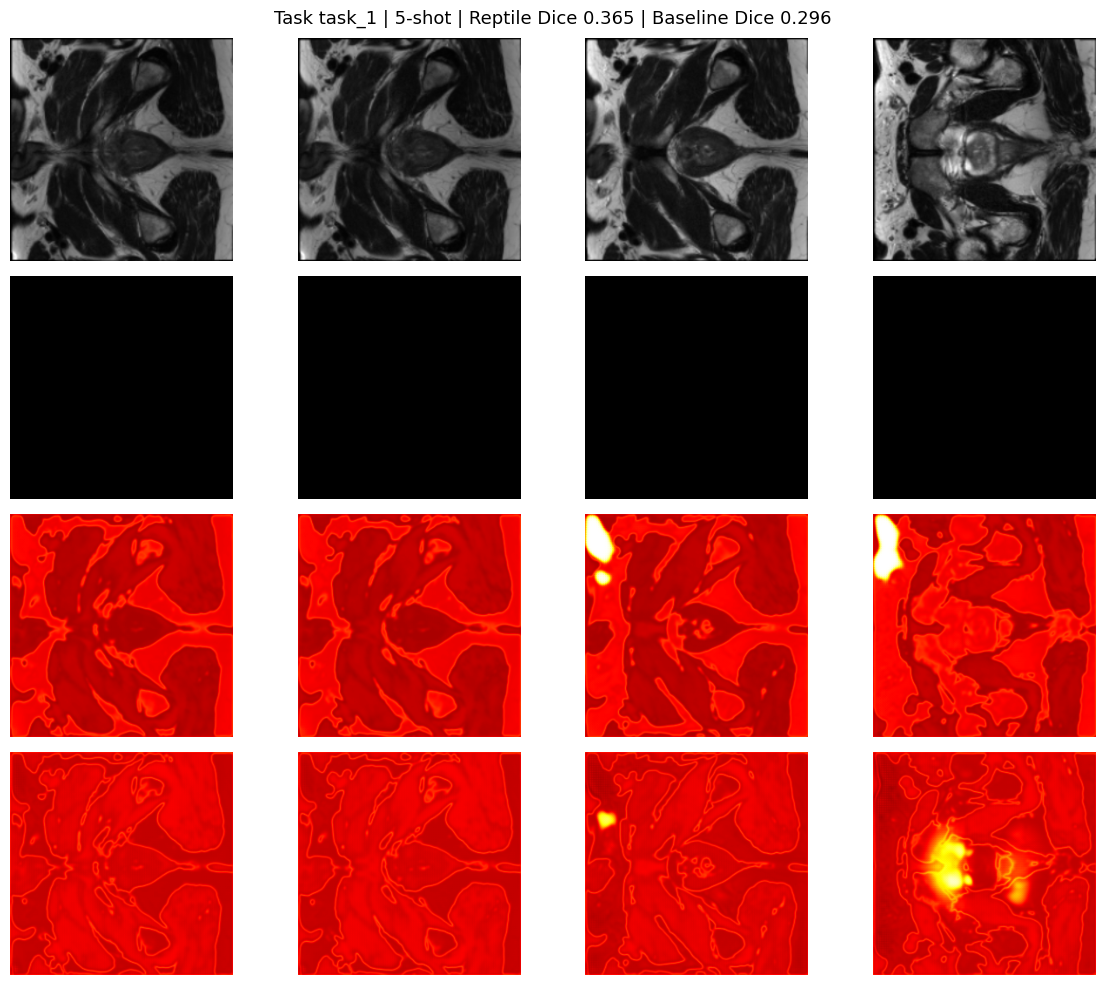

Saved qualitative_task_1_nshot5.png


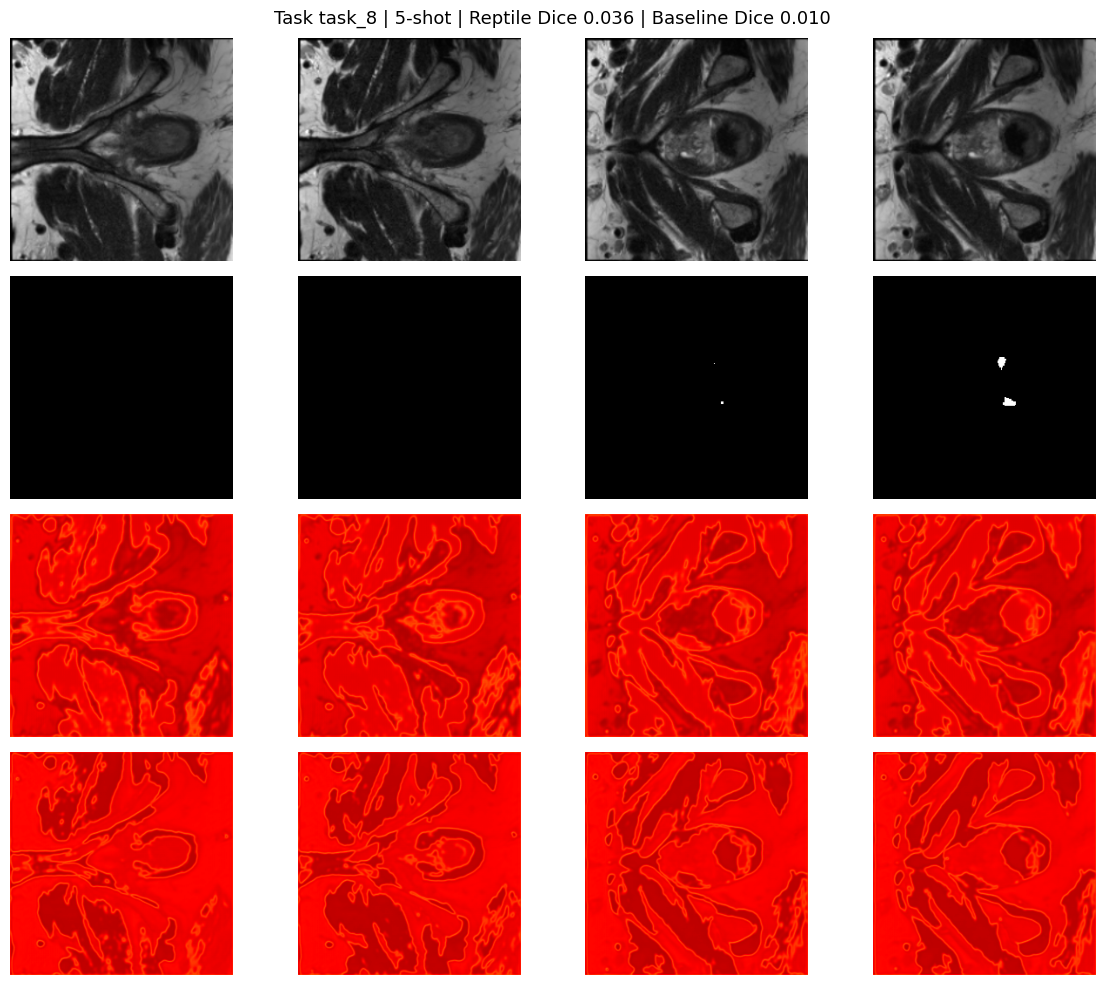

Saved qualitative_task_8_nshot5.png


In [13]:
def qualitative_panel(meta_model, task_dict, task_name,
                      n_shot=5, adapt_steps=20, seed=42, n_cols=4):
    """
    Show: image | GT | Reptile prediction | Baseline prediction (for same query).
    """
    # Reptile adapt
    r_dice, adapted_meta, episode = adapt_and_evaluate(
        meta_model, task_dict,
        n_shot=n_shot,
        adapt_steps=adapt_steps,
        adapt_lr=1e-3,
        seed=seed,
    )

    # Baseline adapt from scratch with same support/query split
    base = UNet().to(DEVICE)
    b_dice, adapted_base, _ = unified_adapt_and_evaluate(
        base,
        task_dict,
        n_shot=n_shot,
        epochs=20,
        lr=1e-3,
        seed=seed,
    )

    # Get one query batch
    q_loader = episode.query_loader(batch_size=n_cols)
    try:
        imgs_b, masks_b = next(iter(q_loader))
    except StopIteration:
        print(f"[{task_name}] No query images available.")
        return

    imgs_b = imgs_b.to(DEVICE)
    masks_b = masks_b.to(DEVICE)

    adapted_meta.eval()
    adapted_base.eval()
    with torch.no_grad():
        preds_r = adapted_meta(imgs_b).cpu().numpy()
        preds_b = adapted_base(imgs_b).cpu().numpy()
        imgs_np = imgs_b.cpu().numpy()
        masks_np = masks_b.cpu().numpy()

    n = min(n_cols, imgs_np.shape[0])
    fig, axes = plt.subplots(4, n, figsize=(3 * n, 10))
    fig.suptitle(
        f"Task {task_name} | {n_shot}-shot "
        f"| Reptile Dice {r_dice:.3f} | Baseline Dice {b_dice:.3f}",
        fontsize=13,
    )

    row_labels = ["MR image", "Ground truth", "Reptile", "Baseline"]
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11)

    for col in range(n):
        axes[0, col].imshow(imgs_np[col, 0], cmap="gray")
        axes[0, col].axis("off")

        axes[1, col].imshow(masks_np[col, 0] * 255, cmap="gray",
                            vmin=0, vmax=255)
        axes[1, col].axis("off")

        axes[2, col].imshow(preds_r[col, 0], cmap="hot", vmin=0, vmax=1)
        axes[2, col].axis("off")

        axes[3, col].imshow(preds_b[col, 0], cmap="hot", vmin=0, vmax=1)
        axes[3, col].axis("off")

    plt.tight_layout()
    out_name = f"qualitative_{task_name}_nshot{n_shot}.png"
    plt.savefig(out_name, dpi=150)
    plt.show()
    print(f"Saved {out_name}")


# Generate qualitative panels for all test tasks at 5-shot
for t_name, t_dict in test_tasks.items():
    qualitative_panel(meta_model, t_dict, t_name, n_shot=5, adapt_steps=20)

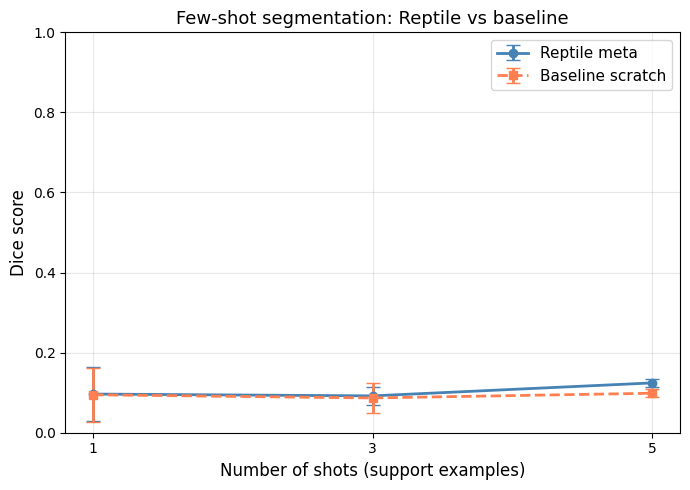

In [14]:
shots = sorted(results.keys())
rmeans = [np.mean(results[s]["reptile"]) for s in shots]
rstds  = [np.std(results[s]["reptile"])  for s in shots]
bmeans = [np.mean(results[s]["baseline"]) for s in shots]
bstds  = [np.std(results[s]["baseline"])  for s in shots]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    shots, rmeans, yerr=rstds,
    marker="o", linewidth=2, capsize=5,
    label="Reptile meta", color="steelblue",
)
ax.errorbar(
    shots, bmeans, yerr=bstds,
    marker="s", linewidth=2, capsize=5,
    linestyle="--",
    label="Baseline scratch", color="coral",
)
ax.set_xlabel("Number of shots (support examples)", fontsize=12)
ax.set_ylabel("Dice score", fontsize=12)
ax.set_title("Few-shot segmentation: Reptile vs baseline", fontsize=13)
ax.set_xticks(shots)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("few_shot_results.png", dpi=150)
plt.show()

In [15]:
import zipfile
from datetime import datetime

summary = {
    "n_outer": N_OUTER,
    "k_inner": K_INNER,
    "inner_lr": INNER_LR,
    "meta_lr": META_LR,
    "adapt_steps": ADAPT_STEPS,
    "baseline_epochs": BASELINE_EPOCHS,
    "device": DEVICE,
    "results": results,
}

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_name = f"summary_EMS741_{stamp}.json"

import json
with open(summary_name, "w") as f:
    json.dump(summary, f, indent=2)

zip_name = f"ems741_outputs_{stamp}.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for fname in [
        "meta_model.pth",
        "meta_training_val_dice.png",
        "meta_training_inner_loss.png",
        "few_shot_results.png",
        "few_shot_summary.csv",
        summary_name,
    ]:
        if os.path.exists(fname):
            z.write(fname)

print("Created", zip_name)

Created ems741_outputs_20260327_164702.zip
